In [4]:
from warnings import simplefilter

import numpy as np


simplefilter(action="ignore", category=FutureWarning)

from test.helpers import (
    SDE,
    simple_batch_sde_solve,
)

import diffrax
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from diffrax import (
    BrownianIncrement,
    Euler,
    SaveAt,
    SpaceTimeTimeLevyArea,
)
from weak_sde import get_weak_sde, weak_error


jax.config.update("jax_enable_x64", True)


def draw_order(results_dict):
    fig, ax = plt.subplots()
    fig.set_dpi(100)

    orders = "Orders:\n"
    scats = []
    for i, (name, result) in enumerate(results_dict.items()):
        steps, errs, slice = result
        steps = steps[slice]
        errs = errs[slice]
        trend = np.polyfit(-np.log(steps), np.log(errs), 1)
        order, _ = trend
        # plot the trend line
        # trend_f = np.poly1d(trend)
        # ax.plot(steps, np.exp(trend_f(-np.log(steps))), linewidth=1.0)

        # plot the points
        scat = ax.scatter(
            steps,
            errs,
            label=f"{name}: {order:.2f}",
        )
        scats.append(scat)

        orders += f"{name}: {order:.2f}\n"
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_ylabel("RMS error")
    ax.set_xlabel("Average number of vector field evaluations")
    ax.legend(fancybox=True, fontsize="large")
    plt.show()


t0 = 0.0
t1 = 4.0
saveat = SaveAt(t1=True)
constant_controller = diffrax.ConstantStepSize()
# sde: SDE = get_mlp_sde(t0, t1, jnp.float64, jr.key(0), 5, y_dim=4)
sde: SDE = get_weak_sde(t0, t1, jnp.float64)

num_samples = 1000000
keys = jr.split(jr.key(0), num_samples)
sde_name = "weak"

In [5]:
ref_filename = f"data/ref_sol_{sde_name}_{num_samples//1000}k.npy"

ref_sol = simple_batch_sde_solve(
    keys,
    sde,
    Euler(),
    BrownianIncrement,
    2**-12,
    constant_controller,
    0,
    saveat,
    use_progress_meter=True,
    use_vbt=False,
)
ref_sols = ref_sol.ys
jnp.save(ref_filename, ref_sols)

ref_sols = jnp.load(ref_filename)
# ref_funs = compute_test_functions(ref_sols)
ref_errs = weak_error(ref_sols, t0, t1)
print(ref_errs)

100.00%|██████████| [01:00<00:00,  1.65%/s]

4.592004572017555e-06


In [6]:
def evaluate_solve(solver, dt, controller):
    sols = simple_batch_sde_solve(
        keys,
        sde,
        solver,
        SpaceTimeTimeLevyArea,
        dt,
        controller,
        0,
        saveat,
        use_progress_meter=True,
        use_vbt=False,
    )
    steps = sols.stats["num_accepted_steps"]
    # errors = comp_fun_dist(sols, ref_funs)
    errors = weak_error(sols.ys, t0, t1)
    return errors, jnp.mean(steps)


def run_const(solver, name, dts=None, steps_mult=1):
    if dts is None:
        dts = [0.5**i for i in range(-2, 8)]
    errors = []
    steps = []
    for dt in dts:
        print(f"dt = {dt}")
        errors_, steps_ = evaluate_solve(solver, dt, constant_controller)
        errors.append(errors_)
        steps.append(steps_)
    errors = jnp.array(errors)
    steps = steps_mult * jnp.array(steps)
    with open(f"data/errors_{sde_name}_sde_{name}_const.npy", "wb") as f:
        jnp.save(f, errors)
        jnp.save(f, steps)
    return errors, steps

In [7]:
from weak_srk.w2ito import W2Ito1


run_const(W2Ito1(jr.key(7)), "w2ito1", dts=[0.5**i for i in range(-2, 8)], steps_mult=3)

with open(f"data/errors_{sde_name}_sde_w2ito1_const.npy", "rb") as f:
    errors_w2ito1_const = jnp.load(f)
    steps_w2ito1_const = jnp.load(f)

dt = 4.0


100.00%|██████████| [00:00<00:00, 5221.80%/s]  


dt = 2.0


100.00%|██████████| [00:00<00:00, 2246.40%/s] 


dt = 1.0


...

100.00%|██████████| [00:02<00:00, 47.64%/s]


dt = 0.015625


100.00%|██████████| [00:04<00:00, 23.98%/s]


dt = 0.0078125


100.00%|██████████| [00:08<00:00, 12.09%/s]


In [8]:
from weak_srk.w2ito import W2Ito2


run_const(W2Ito2(jr.key(7)), "w2ito2", dts=[0.5**i for i in range(-2, 8)], steps_mult=4)

with open(f"data/errors_{sde_name}_sde_w2ito2_const.npy", "rb") as f:
    errors_w2ito2_const = jnp.load(f)
    steps_w2ito2_const = jnp.load(f)

dt = 4.0


100.00%|██████████| [00:00<00:00, 3683.77%/s]  


dt = 2.0


100.00%|██████████| [00:00<00:00, 1598.19%/s] 


dt = 1.0


...

100.00%|██████████| [00:02<00:00, 33.61%/s]


dt = 0.015625


100.00%|██████████| [00:05<00:00, 16.93%/s]


dt = 0.0078125


100.00%|██████████| [00:11<00:00,  8.48%/s]


In [9]:
run_const(Euler(), "euler")

with open(f"data/errors_{sde_name}_sde_euler.npy", "rb") as f:
    errors_euler = jnp.load(f)
    steps_euler = jnp.load(f)

dt = 4.0


100.00%|██████████| [00:00<00:00, 21699.54%/s] 


dt = 2.0


100.00%|██████████| [00:00<00:00, 11835.28%/s]


dt = 1.0


...

100.00%|██████████| [00:00<00:00, 207.08%/s]


dt = 0.015625


100.00%|██████████| [00:00<00:00, 103.54%/s]


dt = 0.0078125


100.00%|██████████| [00:01<00:00, 52.10%/s]


In [10]:
# run_const(Talay(jr.key(7)), "talay")

with open(f"data/errors_{sde_name}_sde_talay_const.npy", "rb") as f:
    errors_talay_const = jnp.load(f)
    steps_talay_const = jnp.load(f)

In [11]:
# ctols = [0.5**i for i in range(4, 16)]
# errors_talay_adaptive = []
# steps_talay_adaptive = []
#
# for ctol in ctols:
#     solver = Talay(jr.key(7), error_mult=ctol, use_levy_area=True)
#     controller = TalayController(ctol, dtmin=2**-10, dtmax=4.0)
#     print(f"ctol = {ctol}")
#     errors_, steps_ = evaluate_solve(solver, 1.0, controller)
#     errors_talay_adaptive.append(errors_)
#     steps_talay_adaptive.append(steps_)
#
# errors_talay_adaptive = jnp.array(errors_talay_adaptive)
# steps_talay_adaptive = jnp.array(steps_talay_adaptive)
# with open(f"data/errors_{sde_name}_sde_talay_adaptive.npy", "wb") as f:
#     jnp.save(f, errors_talay_adaptive)
#     jnp.save(f, steps_talay_adaptive)

with open(f"data/errors_{sde_name}_sde_talay_adaptive.npy", "rb") as f:
    errors_talay_adaptive = jnp.load(f)
    steps_talay_adaptive = jnp.load(f)

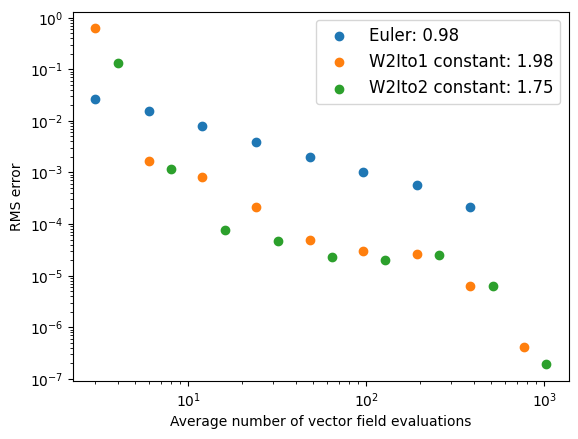

In [14]:
draw_order(
    {
        "Euler": (steps_euler, errors_euler, slice(None, None)),
        # "Talay constant": (steps_talay_const, errors_talay_const, slice(None, None)),
        # "Talay adaptive": (
        #     steps_talay_adaptive,
        #     errors_talay_adaptive,
        #     slice(None, None),
        # ),
        "W2Ito1 constant": (
            steps_w2ito1_const,
            errors_w2ito1_const,
            slice(None, -1),
        ),
        "W2Ito2 constant": (
            steps_w2ito2_const,
            errors_w2ito2_const,
            slice(None, -1),
        ),
    }
)